# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
30,-0.060003,-0.044642,0.044451,-0.019442,-0.009825,-0.007577,0.022869,-0.039493,-0.027129,-0.009362,129.0
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,230.0
331,0.081666,0.050680,-0.025607,-0.036656,-0.070367,-0.046407,-0.039719,-0.002592,-0.041176,-0.005220,199.0
188,0.005383,-0.044642,-0.002973,0.049415,0.074108,0.070710,0.044958,-0.002592,-0.001496,-0.009362,141.0
383,0.005383,0.050680,-0.028840,-0.009113,-0.031840,-0.028871,0.008142,-0.039493,-0.018114,0.007207,88.0
106,-0.096328,-0.044642,-0.076264,-0.043542,-0.045599,-0.034821,0.008142,-0.039493,-0.059471,-0.083920,134.0
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
367,-0.009147,0.050680,0.170555,0.014987,0.030078,0.033759,-0.021311,0.034309,0.033654,0.032059,242.0
404,-0.016412,-0.044642,0.054152,0.070072,-0.033216,-0.027931,0.008142,-0.039493,-0.027129,-0.009362,293.0
32,0.034443,0.050680,0.125287,0.028758,-0.053855,-0.012900,-0.102307,0.108111,0.000272,0.027917,341.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
imputer = SimpleImputer(strategy='mean')
data['bmi'] = imputer.fit_transform(data[['bmi']])

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:

data_knn = data.copy()

knn_imputer = KNNImputer(n_neighbors=5)
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn[['bmi', 'bp']])

print("SimpleImputer (bmi):\n", data[['bmi']].head())
print("\nKNNImputer (bmi):\n", data_knn[['bmi']].head())

SimpleImputer (bmi):
         bmi
0  0.061696
1 -0.051474
2  0.044451
3 -0.011595
4 -0.036385

KNNImputer (bmi):
         bmi
0  0.061696
1 -0.051474
2  0.044451
3 -0.011595
4 -0.036385


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

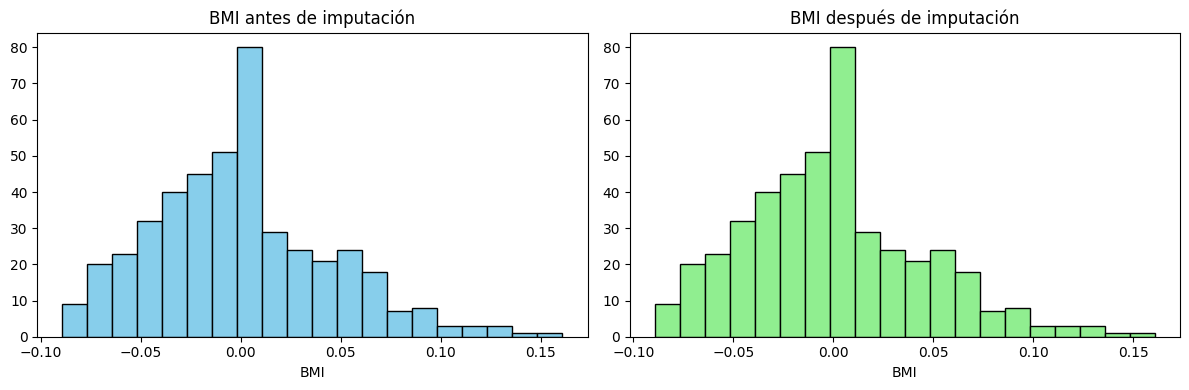

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['bmi'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('BMI antes de imputación')
axes[0].set_xlabel('BMI')

axes[1].hist(data['bmi'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('BMI después de imputación')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()